#Import Dataset

In [7]:
import os
import zipfile

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from google.colab import files

#Feature Engineering

##Keyrecs

###Inter Key Timings Keyrecs

In [8]:
def create_inter_key_timings_keyrecs(group):
    inter_keys = group["DD"].abs().tolist()
    inter_key_string = ",".join(map(lambda x: str(int(x * 1000)), inter_keys[:50]))

    return inter_keys, inter_key_string

###WPM Keyrecs

In [9]:
def calculate_wpm_keyrecs(group):
    total_chars = len(group)
    total_time_sec = (group["DD"].abs().sum())
    total_time_min = (total_time_sec / 60)

    if total_time_min == 0:
        return 0

    wpm = ((total_chars / 5) / total_time_min)

    return round(wpm, 1)

###Backspace Rate Keyrecs

In [10]:
def calculate_backspace_rate_keyrecs(group):
    backspace_count = ((group["key1"].astype(str).str.lower() == "backspace") | (group["key2"].astype(str).str.lower() == "backspace")).sum()
    total_chars = len(group)

    if total_chars == 0:
        return 0

    rate = (backspace_count / total_chars)

    return round(rate, 2)

##Aalto

###Inter Key Timings Aalto

In [11]:
def create_inter_key_timings_aalto(df):
    df = df.sort_values("PRESS_TIME")
    df["NEXT_PRESS"] = (df["PRESS_TIME"].shift(-1))
    df["INTER_KEY"] = (df["NEXT_PRESS"] - df["PRESS_TIME"])

    inter_keys = (df["INTER_KEY"].dropna().astype(int).tolist())
    inter_key_string = ",".join(map(str, inter_keys[:50]))

    return inter_keys, inter_key_string

###WPM Aalto

In [12]:
def calculate_wpm_aalto(df):
    total_chars = len(df)
    duration_ms = (df["RELEASE_TIME"].max() - df["PRESS_TIME"].min())
    duration_min = (duration_ms / 1000 / 60)

    if duration_min == 0:
        return 0

    wpm = ((total_chars / 5) / duration_min)

    return round(wpm, 1)

###Backspace Rate Aalto

In [13]:
def calculate_backspace_rate_aalto(df):
    backspace_count = ((df["LETTER"].astype(str).str.upper() == "BKSP")).sum()
    total_chars = len(df)

    if total_chars == 0:
        return 0

    rate = (backspace_count / total_chars)

    return round(rate, 2)

##Typing Variance

In [14]:
def calculate_typing_variance(inter_keys):
    typing_variance = np.std(inter_keys)

    return round(typing_variance, 2)

##Stress Score

In [15]:
def calculate_stress_score(backspace_rate, typing_variance, wpm):
    normalized_wpm = min(wpm / 120, 1)
    normalized_variance = (typing_variance / (typing_variance + 50))
    stress_score = (0.35 * backspace_rate + 0.4 * normalized_variance + 0.25 * (1 - normalized_wpm))
    stress_score = round(min(max(stress_score, 0), 1), 2)

    return stress_score

#Load Dataset

##Keyrecs Dataset

In [16]:
df_keyrecs = pd.read_csv("https://raw.githubusercontent.com/raihanmeintaro/Dataset/refs/heads/main/Keysroke/KeyRecs%20Dataset.csv", low_memory=False)

Remove Unamed

In [17]:
df_keyrecs = df_keyrecs.loc[:, ~df_keyrecs.columns.str.contains("^Unnamed")]

Rename

In [18]:
df_keyrecs.columns = [
    "participant",
    "session",
    "key1",
    "key2",
    "DU_key1_key1",
    "DD",
    "DU",
    "UD",
    "UU"
]

Numeric

In [19]:
timing_cols = [
    "DU_key1_key1",
    "DD",
    "DU",
    "UD",
    "UU"
]

In [20]:
for col in timing_cols:
    df_keyrecs[col] = pd.to_numeric(df_keyrecs[col], errors='coerce')

df_keyrecs = df_keyrecs.dropna()

print(df_keyrecs.shape)

(562372, 9)


##Feature Engineering Keyrecs

In [21]:
grouped = df_keyrecs.groupby(["participant", "session"])

keyrecs_sessions = []

for idx, ((participant, session), group) in enumerate(grouped):
    if len(group) < 20:
        continue

    inter_keys, inter_key_string = (create_inter_key_timings_keyrecs(group))

    wpm = calculate_wpm_keyrecs(group)

    if wpm == 0:
        continue

    backspace_rate = (calculate_backspace_rate_keyrecs(group))
    typing_variance = (calculate_typing_variance(inter_keys))
    stress_score = (calculate_stress_score(backspace_rate, typing_variance, wpm))

    keyrecs_sessions.append({

        "id":
        f"typ_{idx+1:05d}",

        "user_id":
        participant,

        "wpm":
        wpm,

        "typing_variance":
        typing_variance,

        "backspace_rate":
        backspace_rate,

        "inter_key_timings":
        inter_key_string,

        "stress_label":
        stress_score
    })

keyrecs_df = pd.DataFrame(keyrecs_sessions)

print(keyrecs_df.shape)
print(keyrecs_df["user_id"].nunique())

(198, 7)
99


##Aalto Dataset

In [22]:
!wget -O Keystrokes.zip \
"https://web.archive.org/web/20251127202912if_/https://userinterfaces.aalto.fi/136Mkeystrokes/data/Keystrokes.zip"

--2026-05-18 05:48:41--  https://web.archive.org/web/20251127202912if_/https://userinterfaces.aalto.fi/136Mkeystrokes/data/Keystrokes.zip
Resolving web.archive.org (web.archive.org)... 207.241.237.3
Connecting to web.archive.org (web.archive.org)|207.241.237.3|:443... connected.
HTTP request sent, awaiting response... 302 FOUND
Location: https://web.archive.org/web/20241230182457if_/https://userinterfaces.aalto.fi/136Mkeystrokes/data/Keystrokes.zip [following]
--2026-05-18 05:48:42--  https://web.archive.org/web/20241230182457if_/https://userinterfaces.aalto.fi/136Mkeystrokes/data/Keystrokes.zip
Reusing existing connection to web.archive.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 1572785433 (1.5G) [application/zip]
Saving to: ‘Keystrokes.zip’

Keystrokes.zip      100%[===================>]   1.46G  51.8MB/s    in 39s     

2026-05-18 05:49:33 (38.3 MB/s) - ‘Keystrokes.zip’ saved [1572785433/1572785433]



Extract Dataset

In [23]:
with zipfile.ZipFile("Keystrokes.zip", 'r') as zip_ref:
    zip_ref.extractall("aalto_dataset")

print(os.listdir("aalto_dataset"))

['Keystrokes']


Load Aalto Files

In [24]:
DATASET_PATH = ("aalto_dataset/Keystrokes/files")
files_list = os.listdir(DATASET_PATH)

print("TOTAL FILES:", len(files_list))

TOTAL FILES: 168595


##Feature Engineering Aalto

In [25]:
aalto_sessions = []
MAX_FILES = 2500

for idx, file in enumerate(files_list[:MAX_FILES]):
    try:
        file_path = os.path.join(DATASET_PATH, file)

        df = pd.read_csv(file_path, sep="\t", engine="python", on_bad_lines="skip", encoding_errors="ignore")

        if len(df.columns) != 9:
            continue

        df.columns = [
            "PARTICIPANT_ID",
            "TEST_SECTION_ID",
            "SENTENCE",
            "USER_INPUT",
            "KEYSTROKE_ID",
            "PRESS_TIME",
            "RELEASE_TIME",
            "LETTER",
            "KEYCODE"
        ]

        df["PRESS_TIME"] = pd.to_numeric(df["PRESS_TIME"], errors='coerce')
        df["RELEASE_TIME"] = pd.to_numeric(df["RELEASE_TIME"], errors='coerce')

        df = df.dropna()

        if len(df) < 20:
            continue

        inter_keys, inter_key_string = (create_inter_key_timings_aalto(df))

        if len(inter_keys) < 10:
            continue

        wpm = calculate_wpm_aalto(df)

        if wpm == 0:
            continue

        backspace_rate = (calculate_backspace_rate_aalto(df))
        typing_variance = (calculate_typing_variance(inter_keys))
        stress_score = (calculate_stress_score(backspace_rate,typing_variance, wpm))

        aalto_sessions.append({
            "id":
            f"aalto_{idx+1:05d}",

            "user_id":
            str(
                df[
                    "PARTICIPANT_ID"
                ].iloc[0]
            ),

            "wpm":
            wpm,

            "typing_variance":
            typing_variance,

            "backspace_rate":
            backspace_rate,

            "inter_key_timings":
            inter_key_string,

            "stress_label":
            stress_score
        })

    except:
        continue

aalto_df = pd.DataFrame(aalto_sessions)

print(aalto_df.shape)
print(aalto_df["user_id"].nunique())

(2496, 7)
2496


#Merge Real Dataset

In [26]:
final_df = pd.concat([keyrecs_df, aalto_df], ignore_index=True)

print(final_df.shape)
print(final_df["user_id"].nunique())

final_df.head()

(2694, 7)
2595


,id,user_id,wpm,typing_variance,backspace_rate,inter_key_timings,stress_label
0,typ_00001,p001,35.8,0.55,0.03,"796,1148,172,200,320,1432,280,196,813,183,712,...",0.19
1,typ_00002,p001,39.8,0.36,0.06,"265,207,97,127,248,65,176,129,191,167,191,57,1...",0.19
2,typ_00003,p002,66.8,0.16,0.08,"1166,147,289,240,180,242,114,146,60,185,170,96...",0.14
3,typ_00004,p002,68.2,0.14,0.07,"112,79,90,56,157,42,207,975,65,501,118,56,96,8...",0.13
4,typ_00005,p003,21.3,4.28,0.05,"485,485,735,92,138,108,87,173,60,122,90,108,67...",0.25


##Vizualization

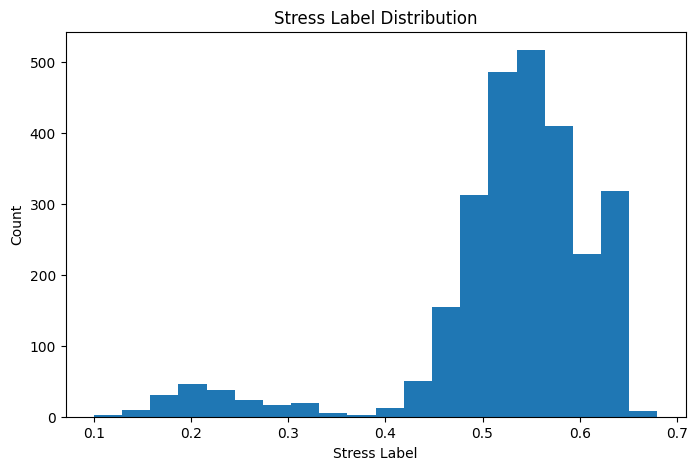

In [27]:
plt.figure(figsize=(8,5))
plt.hist(final_df["stress_label"], bins=20)
plt.xlabel("Stress Label")
plt.ylabel("Count")
plt.title("Stress Label Distribution")
plt.show()

#Synthetic Dataset

In [61]:
synthetic_df = pd.read_csv("https://raw.githubusercontent.com/raihanmeintaro/Dataset/main/Keysroke/Realistic_Minority_Augmentation_Users_v2.csv")

synthetic_df.shape

(1347, 7)

In [62]:
synthetic_df["user_id"].value_counts()

,count
user_id,
syn025,19
syn039,19
syn097,19
syn016,18
syn061,18
...,...
syn027,5
syn090,5
syn101,5


##Select Minority Range from Synthetic

In [63]:
minority_synth = synthetic_df[(synthetic_df["stress_label"] < 0.35) | (synthetic_df["stress_label"] > 0.60)].copy()

minority_synth.shape

(1316, 7)

In [64]:
max_synthetic = int(len(final_df) * 0.30)

minority_synth = minority_synth.sample(n=min(len(minority_synth), max_synthetic), random_state=42)
print("Max Synthetic:", max_synthetic)
print("Used Sythetic:", len(minority_synth))

Max Synthetic: 808
Used Sythetic: 808


#Merge All Datasets

In [65]:
final_balanced_df = pd.concat([final_df, minority_synth],ignore_index=True)

final_balanced_df.shape

(3502, 7)

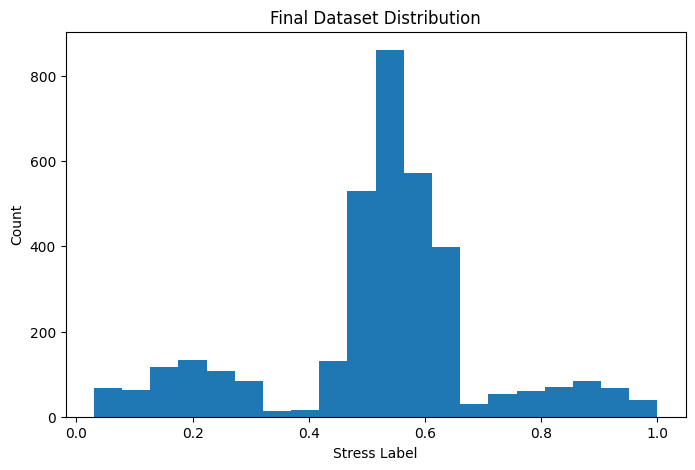

In [66]:
plt.figure(figsize=(8,5))
plt.hist(final_balanced_df["stress_label"], bins=20)
plt.xlabel("Stress Label")
plt.ylabel("Count")
plt.title("Final Dataset Distribution")
plt.show()

In [67]:
print("Real Data:",len(final_df))
print("Synthetic Data:", len(minority_synth))
print("Synthetic Percent:", round((len(minority_synth) / len(final_balanced_df)) * 100, 2), "%")

Real Data: 2694
Synthetic Data: 808
Synthetic Percent: 23.07 %


#Convert Dataset

In [68]:
print(final_balanced_df.shape)
print(final_balanced_df["user_id"].nunique())

(3502, 7)
2715


In [69]:
final_balanced_df.shape

(3502, 7)

In [70]:
final_balanced_df.to_csv("Keystroke_Stress_Dataset.csv", index=False)